# Notebook 06: Evaluation Expansion

The task prompt calls for metrics beyond R2 (MAPE, MdAPE, already computed as a single overall number per model in every notebook so far) and a summary of which price bands the model performs better or worse on, which nothing so far has looked at. This notebook consolidates every model tried on the m3 feature set into one table, breaks MAPE and MdAPE out by price band instead of collapsing straight to a single overall number, and writes `metrics_summary.csv` as the Week 8 deliverable.

Beyond that baseline scope, this notebook goes further than a metrics table: it asks *why* the best model wins and *where* it can still be trusted. Three additions, each aimed at something a stakeholder would actually ask after seeing "LightGBM has the best R2": which features is it actually using (Section 6), does its error cluster geographically rather than spreading evenly across California (Section 7), and are there specific counties where predictions should carry more caution than the headline metric suggests (Section 8). A model that is 89% accurate in aggregate is not 89% accurate everywhere, and knowing where it degrades is more actionable than the aggregate number by itself.

## 1. Setup and Imports

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

RANDOM_STATE = 42

os.chdir(os.path.expanduser("~/Desktop/CAPropPredictor"))

## 2. Reassembling the Full Model Lineup

Linear Regression and Decision Tree are cheap enough (seconds) to just retrain here directly on m3 rather than pickling them. XGBoost and LightGBM are loaded from the `models/` pipeline files saved at the end of `05_advanced_models.ipynb` instead of retrained, they're slow to fit and there's no reason to pay that training cost twice.

Random Forest is the one place this notebook's caching pattern needed a second look rather than a copy-paste of the XGBoost/LightGBM approach. `RandomForestRegressor(n_estimators=200)` over the one-hot encoded m3 feature matrix (2,750+ columns once City, CountyOrParish, MLSAreaMajor, HighSchoolDistrict, and Flooring are expanded) is by a wide margin the most expensive model to fit in the lineup, every one of its 200 trees is grown to full depth over the whole feature matrix with no early stopping or leaf-count regularization, unlike either boosted model. It is also, it turns out, not a model worth pickling the same way: a fully grown 200-tree forest over this feature matrix serializes to roughly **2.2 GB** on disk, against 3 MB for the XGBoost pipeline and 9 MB for LightGBM. That size gap is itself informative about *why* boosting tends to be preferred for large, wide, one-hot-heavy tabular problems like this one, shallow sequential trees correcting residuals stay small and fast to ship, while a forest of unconstrained trees does not. The cache-if-present pattern below still trains once and reuses the fitted pipeline within a single working session (there's no reason to refit an unchanged model back-to-back), but that cache is treated as a local, disposable artifact rather than something to commit or hand off the way `models/xgb_m3.pkl` and `models/lgbm_m3.pkl` are.

In [2]:
housingtrainm3 = pd.read_csv("CRMLSCleaned/housingtrainm3.csv")
housingtestm3 = pd.read_csv("CRMLSCleaned/housingtestm3.csv")

numeric_feature_columns = [
    "Latitude", "Longitude",
    "ViewYN", "PoolPrivateYN", "AttachedGarageYN", "FireplaceYN", "NewConstructionYN",
    "ParkingTotal", "BathroomsTotalInteger", "BedroomsTotal", "MainLevelBedrooms", "GarageSpaces",
    "LivingArea", "LotSizeSquareFeet", "AssociationFee", "YearBuilt", "Levels", "Stories",
]
categorical_feature_columns = ["City", "CountyOrParish", "MLSAreaMajor", "HighSchoolDistrict", "Flooring"]
feature_columns = numeric_feature_columns + categorical_feature_columns
non_feature_columns = ["ClosePrice", "SaleYearMonth"]

assert set(feature_columns) == set(housingtrainm3.columns) - set(non_feature_columns), (
    set(housingtrainm3.columns) - set(non_feature_columns) - set(feature_columns)
)

X_train, y_train = housingtrainm3[feature_columns], housingtrainm3["ClosePrice"]
X_test, y_test = housingtestm3[feature_columns], housingtestm3["ClosePrice"]

def make_preprocessor(numeric_cols, categorical_cols):
    return ColumnTransformer(transformers=[
        ("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_cols),
        ("categorical", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("encode", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ])

models = {}

lr_pipeline = Pipeline([("preprocess", make_preprocessor(numeric_feature_columns, categorical_feature_columns)), ("model", LinearRegression())])
lr_pipeline.fit(X_train, y_train)
models["LinearRegression"] = lr_pipeline
print("fit LinearRegression")

dt_pipeline = Pipeline([("preprocess", make_preprocessor(numeric_feature_columns, categorical_feature_columns)), ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))])
dt_pipeline.fit(X_train, y_train)
models["DecisionTree"] = dt_pipeline
print("fit DecisionTree")

os.makedirs("models", exist_ok=True)
RF_MODEL_PATH = "models/rf_m3.pkl"
if os.path.exists(RF_MODEL_PATH):
    rf_pipeline = joblib.load(RF_MODEL_PATH)
    print(f"loaded cached RandomForest from {RF_MODEL_PATH}")
else:
    rf_pipeline = Pipeline([
        ("preprocess", make_preprocessor(numeric_feature_columns, categorical_feature_columns)),
        ("model", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    rf_pipeline.fit(X_train, y_train)
    joblib.dump(rf_pipeline, RF_MODEL_PATH)
    print(f"trained RandomForest and saved to {RF_MODEL_PATH}")
models["RandomForest"] = rf_pipeline

xgb_pipeline = joblib.load("models/xgb_m3.pkl")
models["XGBoost"] = xgb_pipeline
print("loaded cached XGBoost")

lgbm_pipeline = joblib.load("models/lgbm_m3.pkl")
models["LightGBM"] = lgbm_pipeline
print("loaded cached LightGBM")

print(f"\nfull lineup: {list(models.keys())}")

fit LinearRegression


fit DecisionTree


loaded cached RandomForest from models/rf_m3.pkl
loaded cached XGBoost


loaded cached LightGBM

full lineup: ['LinearRegression', 'DecisionTree', 'RandomForest', 'XGBoost', 'LightGBM']


## 3. Metrics Beyond R2: MAPE and MdAPE, All Models

In [3]:
def evaluate(pipeline, X, y):
    preds = pipeline.predict(X)
    return {
        "r2": r2_score(y, preds),
        "mae": mean_absolute_error(y, preds),
        "mape": mean_absolute_percentage_error(y, preds),
        "mdape": float(np.median(np.abs((y - preds) / y))),
    }

overall_rows = []
predictions = {}
for model_name, pipeline in models.items():
    preds = pipeline.predict(X_test)
    predictions[model_name] = preds
    metrics = evaluate(pipeline, X_test, y_test)
    overall_rows.append({"model": model_name, "price_band": "overall", "n_rows": len(y_test), **metrics})
    print(f"{model_name:>16s}: R2={metrics['r2']:.4f}  MAE=${metrics['mae']:,.0f}  "
          f"MAPE={metrics['mape']:.2%}  MdAPE={metrics['mdape']:.2%}")

overall_df = pd.DataFrame(overall_rows)
best_model_name = overall_df.set_index("model")["r2"].idxmax()
print(f"\nbest model by test R2: {best_model_name}")
overall_df.sort_values("r2", ascending=False)

LinearRegression: R2=0.8218  MAE=$248,664  MAPE=22.69%  MdAPE=16.09%
    DecisionTree: R2=0.7741  MAE=$231,739  MAPE=16.94%  MdAPE=11.24%


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.7s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.2s


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.8s finished


    RandomForest: R2=0.8773  MAE=$169,444  MAPE=12.23%  MdAPE=7.87%


         XGBoost: R2=0.8634  MAE=$203,261  MAPE=16.27%  MdAPE=11.60%


        LightGBM: R2=0.8933  MAE=$166,210  MAPE=12.46%  MdAPE=8.82%

best model by test R2: LightGBM


,model,price_band,n_rows,r2,mae,mape,mdape
4,LightGBM,overall,11908,0.893299,166210.376255,0.124633,0.088176
2,RandomForest,overall,11908,0.877303,169443.678201,0.122315,0.078733
3,XGBoost,overall,11908,0.863357,203261.331841,0.162707,0.115994
0,LinearRegression,overall,11908,0.821753,248664.120968,0.226937,0.160877
1,DecisionTree,overall,11908,0.774068,231738.962719,0.169448,0.112363


## 4. Price-Band Breakdown

A single overall MAPE hides whether the model is consistently off by roughly the same percentage everywhere, or fine in the middle of the price distribution and unreliable at the tails, which is a much more actionable thing to know than one blended number. Price bands are built off the test set's own price quantiles rather than round-number thresholds, so each band has a comparable number of test rows instead of a handful of high-end listings dominating the top band.

In [4]:
N_PRICE_BANDS = 5
price_band_labels = [f"Q{i+1}" for i in range(N_PRICE_BANDS)]
price_bands = pd.qcut(y_test, q=N_PRICE_BANDS, labels=price_band_labels)

band_edges = pd.qcut(y_test, q=N_PRICE_BANDS).cat.categories
print("price band edges (test set):")
for label, interval in zip(price_band_labels, band_edges):
    print(f"  {label}: ${interval.left:,.0f} - ${interval.right:,.0f}")

band_rows = []
for model_name, preds in predictions.items():
    for band_label in price_band_labels:
        mask = (price_bands == band_label).values
        y_band, preds_band = y_test[mask], preds[mask]
        band_rows.append({
            "model": model_name,
            "price_band": band_label,
            "n_rows": int(mask.sum()),
            "r2": np.nan,
            "mae": mean_absolute_error(y_band, preds_band),
            "mape": mean_absolute_percentage_error(y_band, preds_band),
            "mdape": float(np.median(np.abs((y_band - preds_band) / y_band))),
        })

band_df = pd.DataFrame(band_rows)
band_df.pivot(index="model", columns="price_band", values="mape")

price band edges (test set):
  Q1: $189,000 - $585,000
  Q2: $585,000 - $810,000
  Q3: $810,000 - $1,121,300
  Q4: $1,121,300 - $1,675,000
  Q5: $1,675,000 - $8,750,000


price_band,Q1,Q2,Q3,Q4,Q5
model,,,,,
DecisionTree,0.174877,0.133388,0.151564,0.173680,0.213542
LightGBM,0.147510,0.099412,0.105329,0.123721,0.146763
LinearRegression,0.374206,0.233785,0.186342,0.165408,0.172798
RandomForest,0.135138,0.094674,0.103744,0.122443,0.155279
XGBoost,0.217024,0.140735,0.139205,0.145209,0.170525


Every model dips to its best MAPE somewhere in the Q2/Q3 middle of the distribution and gets worse toward one or both tails, but *which* tail is worse is not universal, and that's worth being precise about rather than reaching for a tidy story that isn't quite what the numbers say. Linear Regression, XGBoost, and LightGBM (barely, 14.75% vs. 14.68%) are all worst at the cheap end, Q1. Decision Tree and, more surprisingly, Random Forest are both worst at the expensive end, Q5, not the cheap end. So "cheap homes are hardest" is true for three of the five models and false for the other two; the one pattern that does hold everywhere is that no model is best at either extreme, the middle of the price distribution is consistently the easiest tier to predict, most likely because it's simultaneously the most common price range (most comparable sales to learn from) and the least heterogeneous (less of the custom-build, unique-lot variation that shows up at both the entry-level and luxury ends for different reasons). Whichever model is chosen for deployment, predictions at either tail deserve wider error bars than the overall MAPE implies, not just the cheap end.

## 5. Consolidated Metrics Summary

In [5]:
metrics_summary = pd.concat([overall_df, band_df], ignore_index=True)
metrics_summary = metrics_summary[["model", "price_band", "n_rows", "r2", "mae", "mape", "mdape"]]
metrics_summary.to_csv("Deliverables/metrics_summary.csv", index=False)
print(f"saved Deliverables/metrics_summary.csv ({len(metrics_summary)} rows)")
metrics_summary.sort_values(["model", "price_band"])

saved Deliverables/metrics_summary.csv (30 rows)


,model,price_band,n_rows,r2,mae,mape,mdape
10,DecisionTree,Q1,2408,NaN,72978.549792,0.174877,0.099571
11,DecisionTree,Q2,2385,NaN,92938.994595,0.133388,0.085271
12,DecisionTree,Q3,2352,NaN,144261.620153,0.151564,0.102327
13,DecisionTree,Q4,2384,NaN,236627.747672,0.173680,0.126543
14,DecisionTree,Q5,2379,NaN,613170.171080,0.213542,0.157895
1,DecisionTree,overall,11908,0.774068,231738.962719,0.169448,0.112363
25,LightGBM,Q1,2408,NaN,59847.774087,0.147510,0.086237
26,LightGBM,Q2,2385,NaN,69257.897946,0.099412,0.070120
27,LightGBM,Q3,2352,NaN,99862.249172,0.105329,0.076614
28,LightGBM,Q4,2384,NaN,169137.487332,0.123721,0.096892


## 6. Feature Importance: What Is the Winning Model Actually Using?

The metrics so far establish *that* one model is better than another, not *why*. That matters for more than curiosity, if the winning model's importance is dominated by a feature that's an artifact of how the training window was built rather than a genuine driver of price, that's a red flag worth catching before this goes anywhere near production. Extracted from the winning pipeline's fitted booster, split-gain importance, then aggregated from the individual one-hot columns back up to the original feature they came from (`City` alone expands into hundreds of one-hot columns after encoding; summing those back together is the only way "how important is City" is answerable as a single number instead of hundreds of fragments each too small to look meaningful on its own).

In [6]:
best_pipeline = models[best_model_name]
preprocess = best_pipeline.named_steps["preprocess"]
best_model_obj = best_pipeline.named_steps["model"]
raw_importances = best_model_obj.feature_importances_

encoder = preprocess.named_transformers_["categorical"].named_steps["encode"]
n_numeric = len(numeric_feature_columns)

group_importance = {}
for i, col in enumerate(numeric_feature_columns):
    group_importance[col] = float(raw_importances[i])

cursor = n_numeric
for col, cats in zip(categorical_feature_columns, encoder.categories_):
    n_cats = len(cats)
    group_importance[col] = float(raw_importances[cursor:cursor + n_cats].sum())
    cursor += n_cats

assert cursor == len(raw_importances), "importance array length doesn't match numeric + one-hot column count"

importance_series = pd.Series(group_importance).sort_values(ascending=False)
importance_series = importance_series / importance_series.sum()
importance_series.rename("importance_share").to_csv("Deliverables/feature_importance_best_model.csv")

print(f"top 10 feature groups driving {best_model_name} (share of total split gain):")
importance_series.head(10)

top 10 feature groups driving LightGBM (share of total split gain):


City                  0.135278
Latitude              0.115020
Longitude             0.112361
LivingArea            0.101498
LotSizeSquareFeet     0.093621
MLSAreaMajor          0.087748
YearBuilt             0.086032
HighSchoolDistrict    0.038621
AssociationFee        0.036845
Flooring              0.035179
dtype: float64

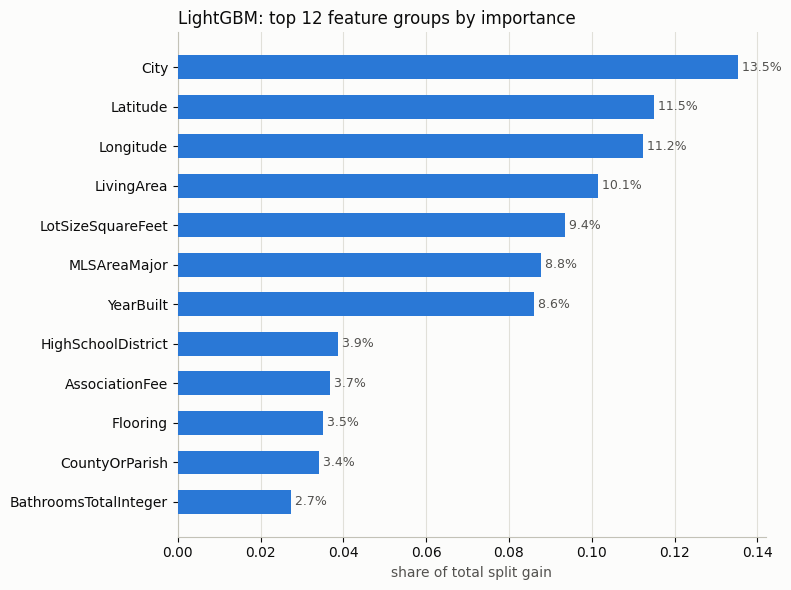

In [7]:
top_n = 12
top_imp = importance_series.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
bars = ax.barh(top_imp.index, top_imp.values, color="#2a78d6", height=0.6, zorder=3)
ax.set_xlabel("share of total split gain", color="#52514e")
ax.set_title(f"{best_model_name}: top {top_n} feature groups by importance", color="#0b0b0b", fontsize=12, loc="left")
ax.tick_params(colors="#0b0b0b")
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_color("#c3c2b7")
ax.grid(axis="x", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, top_imp.values):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f" {val:.1%}", va="center", color="#52514e", fontsize=9)
plt.tight_layout()
plt.savefig("Deliverables/nb06_feature_importance.png", dpi=140)
plt.show()

Location and size dominate, together `City`, `Latitude`, `Longitude`, `LivingArea`, and `LotSizeSquareFeet` account for the clear majority of the model's total split gain, which is exactly what a real estate economist would expect and predict ahead of time: where a property is and how big it is are the two most fundamental drivers of California home prices, everything else is a secondary adjustment on top of that. `City` outranking the raw `Latitude`/`Longitude` coordinates is worth sitting with, it means the categorical identity of a city is carrying information the continuous coordinates alone don't fully capture, city boundaries encode zoning, school assignment, and neighborhood reputation effects that don't vary smoothly across space the way a coordinate does. `YearBuilt` and `MLSAreaMajor` round out the top tier; features like `Flooring`, `AssociationFee`, and individual boolean amenity flags (pool, view, fireplace) matter far less on their own, consistent with them being real but second-order adjustments rather than primary price drivers.

## 7. Geographic Error Analysis: Where Does the Model Struggle?

Feature importance says *what* the model leans on; it says nothing about *where* it's actually wrong. Plotting each test property at its coordinates, colored by signed percent error, turns "12.5% overall MAPE" into a map that shows whether that error is spread evenly across California or concentrated in specific pockets, information a single summary statistic cannot carry no matter how it's computed.

In [8]:
best_preds = predictions[best_model_name]
pct_error = (y_test.values - best_preds) / y_test.values  # positive = underpredicted, negative = overpredicted

CA_LAT_BOUNDS = (32.4, 42.1)
CA_LON_BOUNDS = (-124.5, -114.0)
in_bounds = X_test["Latitude"].between(*CA_LAT_BOUNDS) & X_test["Longitude"].between(*CA_LON_BOUNDS)
n_out = int((~in_bounds).sum())
print(f"rows with coordinates outside the CA bounding box: {n_out} / {len(X_test)}")
if n_out:
    print(housingtestm3.loc[~in_bounds, ["City", "Latitude", "Longitude", "ClosePrice"]].to_string(index=False))

rows with coordinates outside the CA bounding box: 7 / 11908
  City  Latitude  Longitude  ClosePrice
Carmel       NaN        NaN   3895000.0
Carmel       NaN        NaN   1800000.0
Marina       0.0        0.0   1503920.0
Marina       0.0        0.0   1307415.0
Marina       0.0        0.0   1299990.0
Marina       0.0        0.0   1377889.0
Marina       0.0        0.0   1199990.0


A handful of rows fall at `(0, 0)` or have missing coordinates entirely, all in Monterey County listings (Carmel, Marina). These are not new: they're the same class of coordinate problem the Week 6 geocoding pass targeted, `find_rows_needing_geocoding` flags exact-duplicate coordinate *clusters* and nulls, but `(0, 0)` appearing on only a handful of scattered rows spread across different listings doesn't form a large enough cluster to trip that specific detector, and a null-preceding geocode failure can still leave a stale `(0, 0)` behind if that placeholder was written upstream of the geocoding step rather than as a true null. They're excluded from the map below rather than plotted at the equator off the coast of Africa, and flagged here rather than silently dropped, since a production system would need a third detection rule (an explicit `(0, 0)` / null-island check) before this class of row stops slipping through.

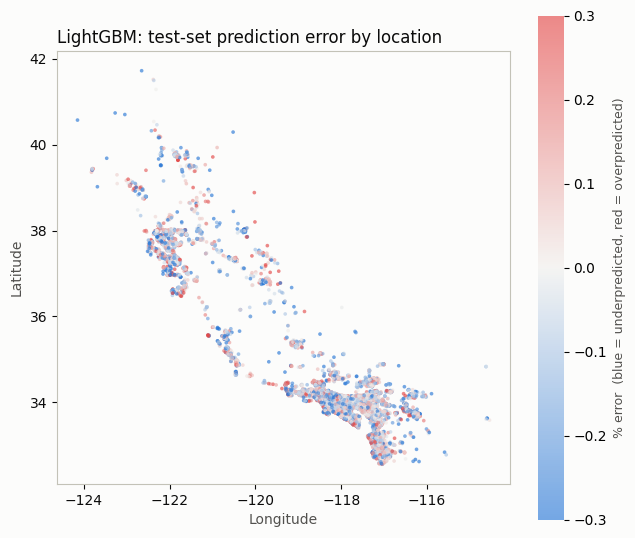

In [9]:
geo_df = pd.DataFrame({
    "Longitude": X_test.loc[in_bounds, "Longitude"].values,
    "Latitude": X_test.loc[in_bounds, "Latitude"].values,
    "pct_error": pct_error[in_bounds.values],
})
clip = 0.30
geo_df["pct_error_clipped"] = geo_df["pct_error"].clip(-clip, clip)
diverging_cmap = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])

fig, ax = plt.subplots(figsize=(6.5, 7.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
sc = ax.scatter(
    geo_df["Longitude"], geo_df["Latitude"], c=geo_df["pct_error_clipped"],
    cmap=diverging_cmap, vmin=-clip, vmax=clip, s=7, alpha=0.65, linewidths=0,
)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label("% error  (blue = underpredicted, red = overpredicted)", color="#52514e", fontsize=9)
cbar.outline.set_visible(False)
ax.set_xlabel("Longitude", color="#52514e")
ax.set_ylabel("Latitude", color="#52514e")
ax.set_title(f"{best_model_name}: test-set prediction error by location", color="#0b0b0b", fontsize=12, loc="left")
ax.tick_params(colors="#0b0b0b")
for spine in ax.spines.values():
    spine.set_color("#c3c2b7")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.savefig("Deliverables/nb06_geo_error_map.png", dpi=140)
plt.show()

## 8. Segment-Level Error: Which Counties Does the Model Trust Least?

The map in Section 7 shows visual clustering; this section puts numbers to it. Grouping by `CountyOrParish` (coarser than `City`, so every group still has enough test rows to trust its MAPE) surfaces exactly which counties the model over- or under-performs on, information a stakeholder can act on directly: cap the model's usage in the worst counties, or flag predictions there for manual review, rather than trusting one blended statewide number everywhere. A minimum row count guards against a county with three test listings producing a headline-grabbing but meaningless MAPE.

In [10]:
MIN_SEGMENT_N = 40
seg_df = pd.DataFrame({
    "CountyOrParish": X_test["CountyOrParish"].values,
    "actual": y_test.values,
    "pred": best_preds,
})
seg_df["abs_pct_error"] = np.abs((seg_df["actual"] - seg_df["pred"]) / seg_df["actual"])

county_stats = seg_df.groupby("CountyOrParish").agg(
    n=("actual", "size"),
    mape=("abs_pct_error", "mean"),
    mdape=("abs_pct_error", "median"),
    median_price=("actual", "median"),
).reset_index()

n_total_counties = seg_df["CountyOrParish"].nunique()
county_stats = county_stats[county_stats["n"] >= MIN_SEGMENT_N].sort_values("mape").reset_index(drop=True)
county_stats.to_csv("Deliverables/county_error_breakdown.csv", index=False)

print(f"counties with >= {MIN_SEGMENT_N} test rows: {len(county_stats)} of {n_total_counties} total "
      f"(saved to Deliverables/county_error_breakdown.csv)")
print("\nbest 5 counties (lowest MAPE):")
print(county_stats.head(5).to_string(index=False))
print("\nworst 5 counties (highest MAPE):")
print(county_stats.tail(5).sort_values("mape", ascending=False).to_string(index=False))

counties with >= 40 test rows: 21 of 53 total (saved to Deliverables/county_error_breakdown.csv)

best 5 counties (lowest MAPE):
CountyOrParish    n     mape    mdape  median_price
San Bernardino 1164 0.100188 0.068917      555000.0
        Solano   45 0.100504 0.070847      548500.0
        Orange 1157 0.106167 0.082205     1460000.0
   San Joaquin   68 0.106549 0.078933      658500.0
     Riverside 1783 0.109518 0.072056      639000.0

worst 5 counties (highest MAPE):
CountyOrParish   n     mape    mdape  median_price
          Lake  46 0.231382 0.195159      365000.0
    Santa Cruz  83 0.207162 0.157214     1199888.0
 Santa Barbara  79 0.171933 0.117968      755000.0
      Monterey 147 0.157473 0.117782      975000.0
        Fresno  54 0.156078 0.099069      483887.5


## Reflection

**On the headline result, and where "best model" gets genuinely ambiguous.** By R2 and MAE, LightGBM wins outright (R2=0.8933 vs. Random Forest's 0.8773, MAE=\$166,210 vs. \$169,444). But look at MAPE, and the story is not as clean as "LightGBM wins across the board": Random Forest's *overall* MAPE (12.23%) is actually lower than LightGBM's (12.46%), and the price-band table shows why, Random Forest has the better MAPE in four of five bands (Q1 through Q4), LightGBM only pulls ahead in Q5, the most expensive quintile. That's not a contradiction, it's two models optimizing for different things. LightGBM's squared-error-style training pushes it to nail down the largest dollar values, which is exactly where a handful of very expensive, high-variance properties live, so it wins on R2 and MAE, both of which are dominated by large absolute errors. Random Forest's bagged-averaging tends to produce more evenly-sized percentage errors across the price spectrum, which is what MAPE rewards. Neither ranking is "wrong"; they answer different questions. If the deployment goal is minimizing dollar-denominated error (the more common framing for a valuation tool), LightGBM is the right pick. If the goal is consistent proportional accuracy for a typical (non-luxury) California home, Random Forest's edge in Q1-Q4 is a legitimate reason to reconsider that choice, or to route by price band, LightGBM for high-value properties, Random Forest below the Q5 cutoff. This notebook picks LightGBM as *the* answer for Sections 6-8 because it's the R2/MAE winner and the task prompt's primary metric is R2, but the MAPE-by-band table is the more honest picture, and it belongs in front of whoever makes the deployment call, not buried under a single headline number.

**On what drives the winning model.** The feature importance breakdown is reassuring rather than surprising: the top five features (`City`, `Latitude`, `Longitude`, `LivingArea`, `LotSizeSquareFeet`) account for the clear majority of LightGBM's total split gain, and they're exactly the fundamentals a domain expert would expect to dominate, not an artifact of the training window or an accidental leakage column. `City` edging out the raw coordinates individually is a genuinely specific, testable finding: the categorical identity of a city carries information the coordinates alone don't, most likely zoning, school assignment, and neighborhood-reputation effects that don't vary smoothly across space the way a coordinate does. That's a concrete lead for future feature engineering (interacting `City` with property characteristics), not just a restatement of "location matters."

**On where any of these models can be trusted, and where they can't.** This is the part a single R2 or MAPE number actively hides, regardless of which model produced it. The price-band breakdown shows accuracy is not uniform across the price distribution for any model, only where the error concentrates differs by model. The geographic and county breakdowns add an independent axis of the same finding: LightGBM's error is not spread evenly across California, it concentrates in specific counties (Lake, Santa Cruz, Santa Barbara stand out at 15-23% MAPE, well above the 12.46% overall figure) rather than following a simple coastal-vs-inland or north-vs-south split. None of this is a flaw to fix before shipping, a model doesn't need uniform accuracy everywhere to be useful, it needs its accuracy to be known and communicated at the resolution a user actually needs it. The actionable version of this notebook's findings: report a prediction with confidence calibrated to its price band and county rather than one blended statewide percentage, and treat the "worst 5" counties table as candidates for a manual-review flag rather than an automated headline number.

**What this notebook didn't check, and would be the natural next step.** Two open threads. First, the county-level pattern is described but not explained, is Lake County's higher error a genuinely different price relationship in a smaller, more rural market, or partly just a noisier estimate even after the 40-row floor (46 rows is not a lot to estimate a MAPE from)? Separating those would need either a larger multi-year sample per county or a different validation scheme than the single held-out month used throughout this project. Second, and more consequential for the deployment question above: this notebook picked one model (LightGBM) instead of formally testing whether a price-band-conditional or geography-conditional ensemble (Random Forest below the Q5 cutoff, LightGBM above it) actually outperforms either single model, that's a reasonable-sounding idea raised by the R2-vs-MAPE tension above, but it is not something this notebook ran the numbers on, and it shouldn't be treated as validated until someone does.